# RiskModels for Omega Point

### ERM3 Orth Risk · a live API session for a partner contact

One sequence, estimated bottom-up on ~3,100 US names daily:

**market → sector → subsector → FF2 style → final residual**

Each layer is the incremental strip after the one above, so exposures never overlap.
**Tradeable hedge legs stop at subsector** — market, sector, and subsector each map to a single
liquid ETF with a signed hedge ratio in dollars. **The FF2 block (SMB + HML) carries no ETF
hedge** — it is the attribution layer that keeps style tilt out of the stock-selection read.

| ERM3 Orth Risk | Contrast with a cross-sectional model |
|---|---|
| Hierarchical orthogonalization — each layer is the incremental regression after the one above | Jointly estimated factors; exposures overlap |
| Market / sector / subsector each hedgeable with **one ETF**; signed HR × notional = a ticket | Factor-mimicking portfolios; not directly tradeable |
| Explained Risk is a **signed covariance share** — layers sum to 100%, and a single layer can print negative; that is information, not error (§3) | R²-style attribution hides sign |
| **L\*** — the API dispatches the shallowest hedge depth whose marginal ER clears a threshold (§4) | Depth choice left to the user |
| **Final residual** — the selection sleeve after the industry cascade *and* the FF2 strip; the skills-paper metric | Style-box heuristics |

### The data behind the API

| Surface | Coverage | Granularity · history |
|---|---|---|
| **Stocks** | ~3,100-name active US universe (nested mc_50 → mc_3000); ~17.7K securities incl. delisted in the master | Daily since 2000; up to 15y over the API |
| **ETFs** | Factor set (SPY + sector + subsector ETFs), search, holdings, factor returns | Daily since 2000 |
| **Mutual funds** | ~9.7K funds; holdings-derived cascade analytics + diagnostics | Monthly (report `teo`) since 2005 — NAV monthly over the API, daily feed upstream |
| **13F filers** | ~8K filers; same holdings-derived portfolio analytics | Quarterly |
| **Macro** | Rates, USD, oil, gold, BTC, VIX — correlation vs the residual layers | Daily |

**PIT & symbology infrastructure:**

- **Bitemporal by construction.** Every response carries lineage headers —
  `X-Data-As-Of` (the date the data describes) and `X-Data-Filing-Date` (when it became
  knowable). Holdings analytics honor the ~60-day filing lag — no look-ahead — and
  quarterly fundamentals are PIT-gated the same way.
- **Survivorship-aware.** The security master retains delisted names, and universe
  membership (mc_50 → mc_3000) is a point-in-time mask, not a backfilled list.
- **One symbology spine.** A canonical `bw_sym_id` (FIGI-first, with ISIN/ticker
  fallbacks) keys every store; N-PORT and 13F holdings are CUSIP-bridged onto it. Funds
  resolve to a stable `bw_fund_id` (SEC series), 13F filers to `bw_filer_id` (CIK/LEI) —
  so stocks, funds, and filers join cleanly across the whole surface.

**API process, at the highest level:**

- **Batch and portfolio surfaces**, not just single names: `POST /batch/analyze`,
  `POST /batch/lstar` (100 tickers/call), and portfolio returns / risk-index / snapshot —
  the "bring your book" pattern in Part III.
- **Metered and auditable.** Each call returns its own cost header; panels and PDF
  tearsheets are server-rendered from the same registry.

**This session is API-only.** Long-history zarr access can be permissioned later.

**Docs:** [API guide](https://riskmodels.app/docs/api) · [Interactive reference](https://riskmodels.app/api-reference) · [Get an API key](https://riskmodels.app/get-key) · CLI twin: `python/stocks_and_funds_quickstart.py`


## Setup · Install once

In Google Colab, run the next cell once. Locally, install the same packages in your environment.


In [1]:
import sys
import subprocess

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", "-U",
        "riskmodels-py", "pandas", "matplotlib", "requests", "python-dotenv",
    ])
    print("Installed RiskModels and notebook dependencies.")
else:
    print("Local notebook: pip install -U riskmodels-py pandas matplotlib requests python-dotenv")


Local notebook: pip install -U riskmodels-py pandas matplotlib requests python-dotenv


## Setup · Connect securely

`quickstart_connect()` looks for `RISKMODELS_API_KEY` in the environment, a local `.env` / `.env.local`, or Colab Secrets. If missing, it prompts securely. The key is never printed.


In [2]:
import contextlib
import io
import os
from pathlib import Path
from typing import Any

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
from IPython.display import Image, display

from riskmodels import RiskModelsClient
from riskmodels.notebook import quickstart_connect

# Connect quietly when the key is already discoverable; interactive prompt otherwise.
_env_ready = bool(os.environ.get("RISKMODELS_API_KEY")) or any(
    (base / name).exists()
    for base in (Path.cwd(), Path.cwd().parent)
    for name in (".env.local", ".env")
)
with contextlib.redirect_stderr(io.StringIO()) if _env_ready else contextlib.nullcontext():
    session, BASE_URL, API_KEY = quickstart_connect()
os.environ.setdefault("RISKMODELS_API_KEY", API_KEY)
os.environ.setdefault("RISKMODELS_BASE_URL", BASE_URL)
client = RiskModelsClient.from_env()

OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

# ── One visual language, matched to the server-rendered snapshot panels ──────
NAVY = "#1B2A4A"
LAYER_COLORS = {
    "Market": "#64748B",
    "Sector": "#1D6FA8",
    "Subsector": "#7C3AED",
    "Style (FF2)": "#0D9488",     # attribution only — no ETF hedge
    "Residual": "#16A34A",
    "L* residual": "#16A34A",
    "Final residual": "#16A34A",
    "Gross": NAVY,
}
plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlecolor": NAVY, "axes.titleweight": "bold", "axes.titlesize": 12,
    "axes.grid": True, "axes.grid.axis": "y", "grid.color": "#E5E9F0", "grid.linewidth": 0.8,
    "axes.edgecolor": "#94A3B8", "axes.labelcolor": "#334155",
    "xtick.color": "#475569", "ytick.color": "#475569",
    "legend.frameon": False,
})


def api_get(path: str, **params: Any) -> tuple[dict, dict]:
    response = session.get(f"{BASE_URL}{path}", params=params, timeout=90)
    if not response.ok:
        raise RuntimeError(f"GET {path} failed ({response.status_code}): {response.text[:500]}")
    headers = {
        "data_as_of": response.headers.get("X-Data-As-Of"),
        "filing_date": response.headers.get("X-Data-Filing-Date"),
        "model_version": response.headers.get("X-Risk-Model-Version"),
        "cost_usd": response.headers.get("X-API-Cost-USD"),
    }
    return response.json(), headers


def api_post(path: str, **body: Any) -> tuple[dict, dict]:
    response = session.post(f"{BASE_URL}{path}", json=body, timeout=90)
    if not response.ok:
        raise RuntimeError(f"POST {path} failed ({response.status_code}): {response.text[:500]}")
    return response.json(), {"cost_usd": response.headers.get("X-API-Cost-USD")}


def first_value(series: pd.Series, *names: str, default=None):
    for name in names:
        if name in series.index and pd.notna(series[name]):
            return series[name]
    return default


def pick_col(frame: pd.DataFrame, *names: str) -> str | None:
    return next((name for name in names if name in frame.columns), None)


def waterfall(ax, steps: dict, total_label="Gross", title=None):
    """Stacked waterfall: ordered {layer: contribution}. Bars float at the running
    cumulative, residual layers hatched, total bar in navy, connectors dotted."""
    cum = 0.0
    for i, (lab, v) in enumerate(steps.items()):
        hatch = "//" if "residual" in lab.lower() else None
        ax.bar(i, v, bottom=cum, width=0.62, color=LAYER_COLORS.get(lab, "#94A3B8"),
               hatch=hatch, edgecolor="white", linewidth=0.5)
        ax.annotate(f"{v:+.1%}", (i, cum + v), ha="center",
                    va="bottom" if v >= 0 else "top", fontsize=9, fontweight="bold",
                    color="#334155" if v >= 0 else "#B45309")
        cum += v
        ax.plot([i + 0.31, i + 0.69], [cum, cum], ls=":", color="#9CA3AF", lw=1)
    n = len(steps)
    ax.bar(n, cum, width=0.62, color=NAVY)
    ax.annotate(f"{cum:+.1%}", (n, max(cum, 0.0)), ha="center", va="bottom",
                fontsize=10, fontweight="bold", color=NAVY)
    ax.set_xticks(range(n + 1))
    ax.set_xticklabels(list(steps) + [total_label], fontsize=9)
    levels = np.concatenate([[0.0], np.cumsum(list(steps.values()))])
    hi, lo = float(levels.max()), float(min(0.0, levels.min()))
    span = (hi - lo) or 1.0
    ax.set_ylim(lo - (0.12 * span if lo < 0 else 0.0), hi + 0.15 * span)
    ax.axhline(0, color="#9CA3AF", lw=0.8)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    if title:
        ax.set_title(title, loc="left")


def cum_with_t0(contrib: pd.DataFrame, dates) -> pd.DataFrame:
    """Arithmetic cumulative attribution anchored at 0: prepends a zero row one
    business day before the first date so every line starts at exactly 0."""
    dates = pd.to_datetime(pd.Series(list(dates)).reset_index(drop=True))
    cum = contrib.reset_index(drop=True).fillna(0).cumsum()
    cum.index = dates
    t0 = dates.iloc[0] - pd.tseries.offsets.BDay(1)
    return pd.concat([pd.DataFrame(0.0, index=[t0], columns=cum.columns), cum])


def attribution_lines(ax, frame: pd.DataFrame, title=None):
    """Cumulative attribution lines (frame indexed by date, anchored at 0).
    Gross heavy navy; layers in the shared palette; dodged end-value labels.
    Ticks are clipped to the data range so the label margin shows no phantom dates."""
    dates = frame.index
    span = float(np.nanmax(frame.values) - np.nanmin(frame.values)) or 1.0
    for col in frame.columns:
        lw, color = (2.4, NAVY) if col == "Gross" else (1.5, LAYER_COLORS.get(col, "#94A3B8"))
        ax.plot(dates, frame[col], color=color, lw=lw)
    y_last = None
    for col, v in frame.iloc[-1].sort_values().items():
        y = v if y_last is None else max(v, y_last + 0.055 * span)
        y_last = y
        color = NAVY if col == "Gross" else LAYER_COLORS.get(col, "#94A3B8")
        ax.annotate(f" {col} {v:+.1%}", (dates[-1], y), color=color,
                    fontsize=8.5, va="center", fontweight="bold")
    ax.axhline(0, color="#9CA3AF", lw=0.8)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_xlim(dates[0], dates[-1] + (dates[-1] - dates[0]) * 0.24)
    last_num = mdates.date2num(dates[-1])
    ax.set_xticks([t for t in ax.get_xticks() if t <= last_num])
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    if title:
        ax.set_title(title, loc="left")


print("Connected to", BASE_URL)
print("Artifacts will save under", OUTPUT_DIR.resolve())


RiskModels REST session ready (key prefix rm_agent_live_n2…). Keys & plans: https://riskmodels.app/get-key
Connected to https://riskmodels.app/api
Artifacts will save under /Users/conradgann/BW_Code/Omega_RiskModels/notebooks/output


## Setup · Choose subjects

Change these and rerun. Keep the demo book small — one batch call.


In [3]:
STOCK_TICKER = "NVDA"   # Try AAPL, JPM, TSLA
STOCK_YEARS = 3
FUND_QUERY = "AGTHX"    # Ticker or part of a mutual-fund name
NOTIONAL_USD = 10_000_000  # Dollar hedge ticket size

# Tiny "bring your book" weights — what an Omega workflow would POST
BOOK = {"NVDA": 0.25, "AAPL": 0.25, "MSFT": 0.25, "JPM": 0.25}

# Pre-rendered / server panel tiles (API). `_full` is the composed Deep Dive page.
PANEL_SLUGS = (
    "l3_explained_risk_hbar",
    "hedge_notionals_hbar",
    "hedge_depth_retained",
)

print({
    "stock": STOCK_TICKER,
    "stock_years": STOCK_YEARS,
    "fund_query": FUND_QUERY,
    "notional_usd": NOTIONAL_USD,
    "book": BOOK,
})


{'stock': 'NVDA', 'stock_years': 3, 'fund_query': 'AGTHX', 'notional_usd': 10000000, 'book': {'NVDA': 0.25, 'AAPL': 0.25, 'MSFT': 0.25, 'JPM': 0.25}}


# Part I · Stock — the whole model in one picture

## 1 · Cumulative return attribution

One call (`get_ticker_returns`) applies the full hierarchy to the chosen window of
realized returns. Left: arithmetic cumulative attribution (`cumsum`) — additive layers,
every line anchored at 0 (a t₀ row is prepended). Right: the same window totalled as a
waterfall — lines and bars agree by construction. *Residual here is the L3 industry
residual (pre-FF2).*

Everything that follows drills into this picture: where the risk sits today (§2), why a
layer can print negative (§3), and how deep the API says to hedge (§4).


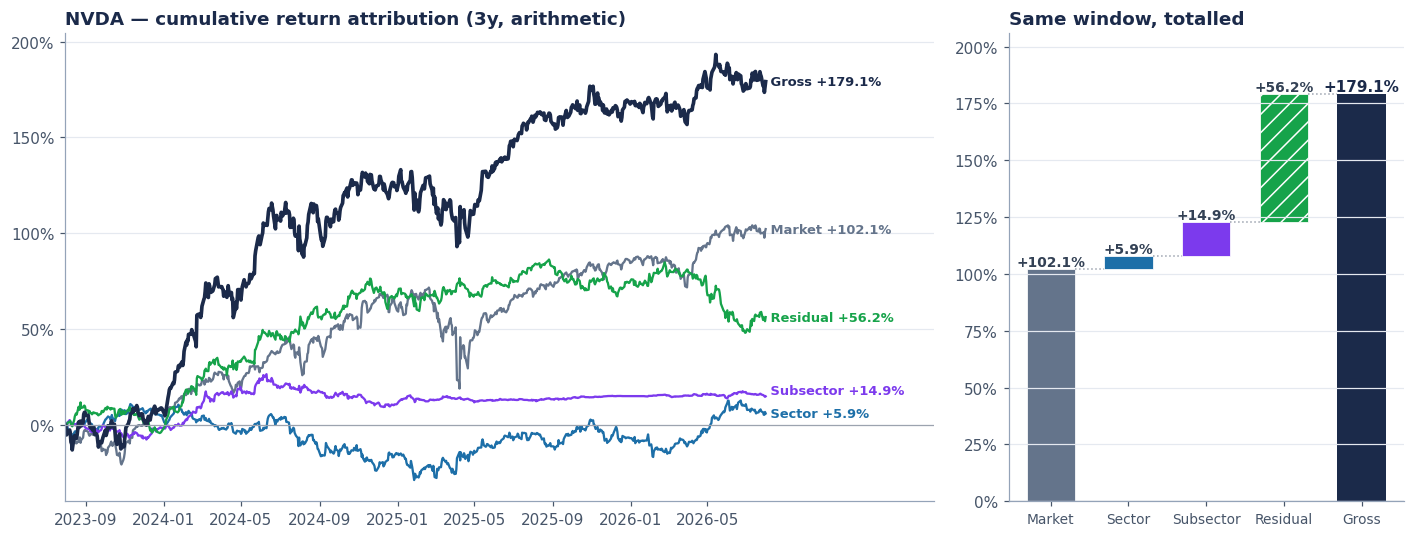

Mean absolute daily identity gap: 0.000000%


In [4]:
stock_history = client.get_ticker_returns(STOCK_TICKER, years=STOCK_YEARS).copy()
if stock_history.empty:
    raise ValueError(f"No return history returned for {STOCK_TICKER}.")

stock_history["date"] = pd.to_datetime(stock_history["date"])
stock_history = stock_history.sort_values("date").reset_index(drop=True)

gross_col = pick_col(stock_history, "returns_gross", "gross_return")
l1_fr = pick_col(stock_history, "l1_factor_return", "l1_fr")
l2_fr = pick_col(stock_history, "l2_factor_return", "l2_fr")
l3_fr = pick_col(stock_history, "l3_factor_return", "l3_fr")
l1_cfr = pick_col(stock_history, "l1_combined_factor_return", "l1_cfr")
l2_cfr = pick_col(stock_history, "l2_combined_factor_return", "l2_cfr")
l3_cfr = pick_col(stock_history, "l3_combined_factor_return", "l3_cfr")
l3_rr = pick_col(stock_history, "l3_residual_return", "l3_rr")

if gross_col is None or l3_cfr is None:
    raise KeyError("Expected gross and L3 factor-return fields are not present. Inspect stock_history.columns.")

contrib = pd.DataFrame(index=stock_history.index)
contrib["Market"] = stock_history[l1_fr] if l1_fr else stock_history[l1_cfr]
contrib["Sector"] = stock_history[l2_fr] if l2_fr else stock_history[l2_cfr] - stock_history[l1_cfr]
contrib["Subsector"] = stock_history[l3_fr] if l3_fr else stock_history[l3_cfr] - stock_history[l2_cfr]
contrib["Residual"] = stock_history[l3_rr] if l3_rr else stock_history[gross_col] - stock_history[l3_cfr]
contrib["Gross"] = stock_history[gross_col]

cumulative = cum_with_t0(contrib, stock_history["date"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [2.2, 1]})
attribution_lines(ax1, cumulative,
                  title=f"{STOCK_TICKER} — cumulative return attribution ({STOCK_YEARS}y, arithmetic)")
totals = contrib[["Market", "Sector", "Subsector", "Residual"]].sum()
waterfall(ax2, totals.to_dict(), total_label="Gross", title="Same window, totalled")
plt.tight_layout()
plt.show()

check = (contrib[["Market", "Sector", "Subsector", "Residual"]].sum(axis=1) - contrib["Gross"]).abs()
print("Mean absolute daily identity gap:", f"{check.mean():.6%}")


## 2 · Current risk: signed variance shares, three ETF legs, dollar ticket

**Explained Risk (ER)** is a signed covariance share. At L3, market + sector + subsector +
residual ≈ 100% — and a single layer can print negative (§3).

**Hedge Ratio (HR)** is ETF dollars per $1 of stock, signed. **Hedge legs stop at
subsector** — market, sector, subsector are the tradeable layers. The FF2 strip further
splits the residual for attribution, but has no ETF hedge.

Scale HR by `NOTIONAL_USD` for a trade ticket a PM recognizes.


,Value
Ticker,NVDA
As of,2026-07-31
Price,200.75
23d annualized volatility,0.41
L3 ER total,1.00
Ticket notional,10000000


,Layer,ETF,HR ($ ETF / $1 stock),Notional hedge ($)
0,Market,SPY,-0.738,"$-7,381,842"
1,Sector,sector ETF,-0.186,"$-1,856,115"
2,Subsector,subsector ETF,-0.350,"$-3,496,806"


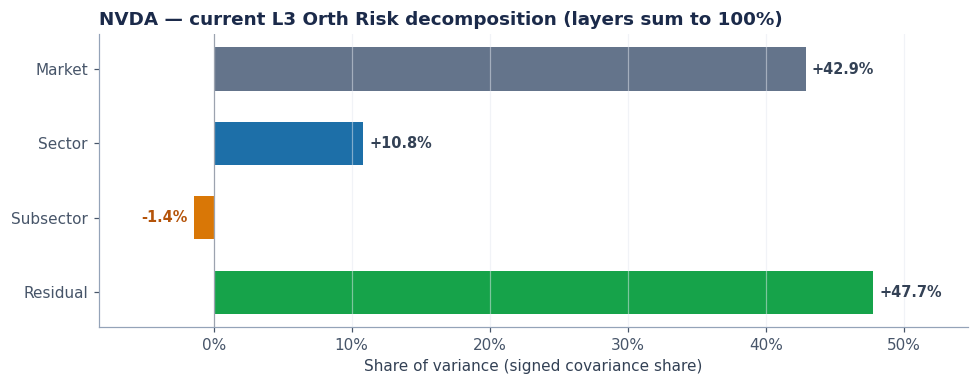

Negative layer (Subsector) — not an error; see §3, and §4 for the L* response.


In [5]:
metrics_df = client.get_metrics(STOCK_TICKER, as_dataframe=True)
if metrics_df.empty:
    raise ValueError(f"No metrics returned for {STOCK_TICKER}.")

row = metrics_df.iloc[-1]

er = pd.Series({
    "Market": first_value(row, "l3_market_er", "l3_mkt_er"),
    "Sector": first_value(row, "l3_sector_er", "l3_sec_er"),
    "Subsector": first_value(row, "l3_subsector_er", "l3_sub_er"),
    "Residual": first_value(row, "l3_residual_er", "l3_res_er"),
}, dtype="float64")

hedge = pd.DataFrame([
    {
        "Layer": "Market",
        "ETF": first_value(row, "market_factor_etf", "market_etf", default="SPY"),
        "HR ($ ETF / $1 stock)": first_value(row, "l3_market_hr", "l3_mkt_hr"),
    },
    {
        "Layer": "Sector",
        "ETF": first_value(row, "sector_etf", default="sector ETF"),
        "HR ($ ETF / $1 stock)": first_value(row, "l3_sector_hr", "l3_sec_hr"),
    },
    {
        "Layer": "Subsector",
        "ETF": first_value(row, "subsector_etf", default="subsector ETF"),
        "HR ($ ETF / $1 stock)": first_value(row, "l3_subsector_hr", "l3_sub_hr"),
    },
])
hedge["Notional hedge ($)"] = hedge["HR ($ ETF / $1 stock)"] * NOTIONAL_USD

snapshot = pd.DataFrame({
    "Value": {
        "Ticker": STOCK_TICKER,
        "As of": first_value(row, "date", "teo", default="latest"),
        "Price": first_value(row, "price_close"),
        "23d annualized volatility": first_value(row, "vol_23d"),
        "L3 ER total": er.sum(min_count=1),
        "Ticket notional": NOTIONAL_USD,
    }
})

display(snapshot)
hedge_display = hedge.copy()
hedge_display["HR ($ ETF / $1 stock)"] = hedge_display["HR ($ ETF / $1 stock)"].map(
    lambda x: f"{x:.3f}" if pd.notna(x) else "—"
)
hedge_display["Notional hedge ($)"] = hedge_display["Notional hedge ($)"].map(
    lambda x: f"${x:,.0f}" if pd.notna(x) else "—"
)
display(hedge_display)

er_plot = er.dropna()
fig, ax = plt.subplots(figsize=(9, 3.6))
labels = list(er_plot.index)[::-1]
values = list(er_plot.values)[::-1]
colors = [LAYER_COLORS.get(k, "#94A3B8") if v >= 0 else "#D97706" for k, v in zip(labels, values)]
ax.barh(labels, values, color=colors, height=0.58)
for k, v in zip(labels, values):
    ax.annotate(f"{v:+.1%}", (v, k), ha="left" if v >= 0 else "right",
                va="center", fontsize=9.5, fontweight="bold",
                color="#334155" if v >= 0 else "#B45309",
                xytext=(4 if v >= 0 else -4, 0), textcoords="offset points")
ax.axvline(0, color="#9CA3AF", lw=0.8)
ax.grid(axis="x", alpha=0.5)
ax.grid(axis="y", visible=False)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlabel("Share of variance (signed covariance share)")
ax.set_title(f"{STOCK_TICKER} — current L3 Orth Risk decomposition (layers sum to {er_plot.sum():.0%})", loc="left")
ax.margins(x=0.14)
plt.tight_layout()
plt.show()

if (er_plot < 0).any():
    neg = ", ".join(er_plot[er_plot < 0].index)
    print(f"Negative layer ({neg}) — not an error; see §3, and §4 for the L* response.")


## 3 · Why a variance share can be negative

ER is a **signed covariance share** — β·Cov(layer, stock) / Var(stock) — not an incremental
R². The layers still sum to 100%, but any single layer can print negative.

For NVDA it is structural: NVDA is the dominant weight in SMH, so once SPY and XLK are
stripped out, the orthogonal subsector factor is effectively *semis ex-NVDA* — and NVDA has
been trading **against** that spread. A negative ER is a trade instruction, not a model
artifact: shorting the SMH leg "by the book" would **add** variance.

The right response is a shallower hedge — which is exactly what **L\*** automates, next.


## 4 · L\* — let the API pick the hedge depth

`GET /lstar` dispatches, per date, the **shallowest** cascade level whose marginal
explained-return clears a threshold (default 1%), and returns that level's hedge ratios
plus the daily residual series. It is the productized answer to "how deep do I hedge?" —
and it turns §3 into a rule: when the subsector leg stops paying for itself, L\* stops at L2.

Two conventions to keep straight, both served by the API:

- **Hedge legs stop at subsector.** L\* only dispatches among L1/L2/L3 — the tradeable depths.
- **FF2 has no ETF hedge.** The style block splits the L\* residual into *style* +
  *stock-specific* variance shares (a variance-ratio diagnostic on the L\* basis:
  style + stock-specific ≈ the L\* residual's share). It is what keeps style tilt out of the
  selection read — the skills-paper skill target is the residual **after** FF2.


L* today for NVDA: L2  (marginal-ER threshold 1%)


,Residual ER,"Ticket on $10,000,000"
Depth,,
L1,57.1%,"short $18,731,163 SPY"
L2 ← L*,46.3%,"short $3,670,187 SPY · short $8,836,512 XLK"
L3,47.7%,"short $7,381,842 SPY · short $1,856,115 XLK · ..."


FF2 split of the L* residual: style 10.2% + stock-specific 47.5% ≈ 57.7% variance share (variance-ratio convention, L* basis). No ETF hedge on FF2 — the stock-specific share is the skills-paper skill basis.


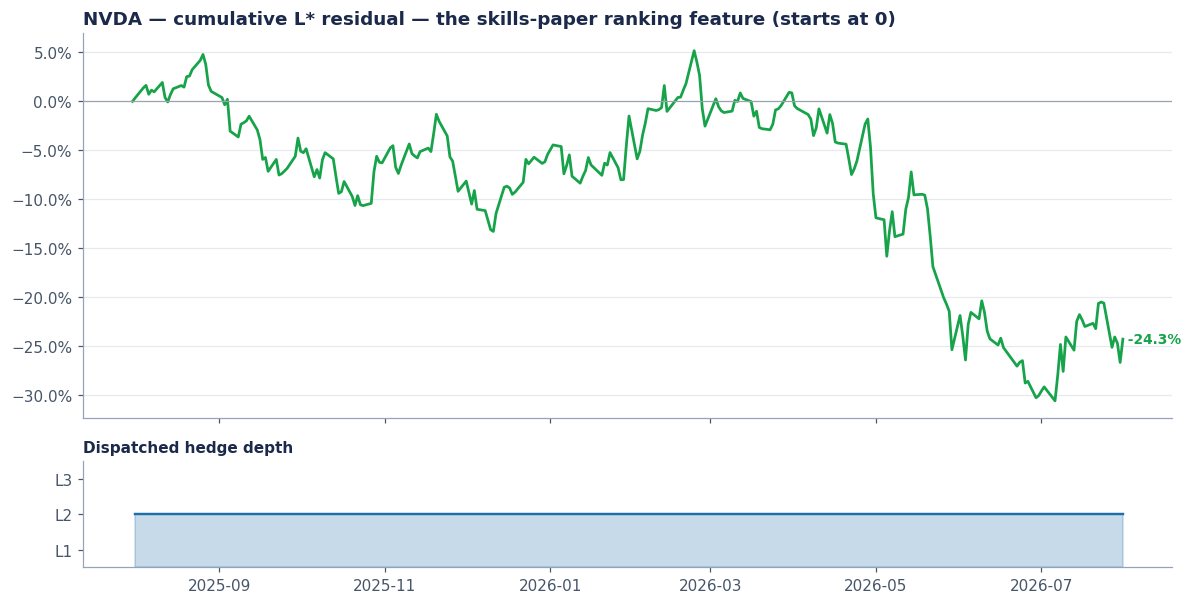

In [6]:
lstar_body, lstar_headers = api_get("/lstar", ticker=STOCK_TICKER)
lstar_df = pd.DataFrame({
    "date": pd.to_datetime(lstar_body["dates"]),
    "level": lstar_body["lstar"],
    "residual_return": lstar_body["residual_return"],
})
level_now = lstar_df["level"].dropna().iloc[-1]
print(f"L* today for {STOCK_TICKER}: {level_now}  (marginal-ER threshold {lstar_body.get('threshold_used', 0.01):.0%})")

# Hedge-depth menu: L1 / L2 / L3 with the L* dispatch highlighted
dec, _ = api_post("/decompose", ticker=STOCK_TICKER)
hedge_levels = dec.get("hedge_levels") or {}
menu_rows = []
for lvl in ["L1", "L2", "L3"]:
    blk = hedge_levels.get(lvl) or {}
    etfs = blk.get("hedge_etfs") or {}
    legs = []
    for leg_name in ["market", "sector", "subsector"]:
        hr = blk.get(f"{leg_name}_hr")
        etf = etfs.get(leg_name)
        if hr is not None and etf:
            side = "short" if hr < 0 else "long"
            legs.append(f"{side} ${abs(hr) * NOTIONAL_USD:,.0f} {etf}")
    res_er = blk.get("residual_er")
    menu_rows.append({
        "Depth": lvl + ("  ← L*" if lvl == hedge_levels.get("recommended_level") else ""),
        "Residual ER": f"{res_er:.1%}" if res_er is not None else "—",
        f"Ticket on ${NOTIONAL_USD:,.0f}": " · ".join(legs) or "—",
    })
display(pd.DataFrame(menu_rows).set_index("Depth"))

# FF2 diagnostic on the L* residual — attribution, never a hedge leg
style_ev = (dec.get("style") or {}).get("explained_variance")
ss_ev = (dec.get("stock_specific") or {}).get("explained_variance")
if style_ev is not None and ss_ev is not None:
    print(
        f"FF2 split of the L* residual: style {style_ev:.1%} + stock-specific {ss_ev:.1%} "
        f"≈ {style_ev + ss_ev:.1%} variance share (variance-ratio convention, L* basis). "
        "No ETF hedge on FF2 — the stock-specific share is the skills-paper skill basis."
    )

# Residual path at the dispatched depth + the dispatch itself
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(11, 5.6), sharex=True, gridspec_kw={"height_ratios": [4, 1.1]}
)
cum_resid = cum_with_t0(
    lstar_df[["residual_return"]].rename(columns={"residual_return": "L* residual"}),
    lstar_df["date"],
)
ax1.plot(cum_resid.index, cum_resid["L* residual"], color=LAYER_COLORS["L* residual"], lw=1.8)
ax1.annotate(f" {cum_resid['L* residual'].iloc[-1]:+.1%}",
             (cum_resid.index[-1], cum_resid["L* residual"].iloc[-1]),
             color=LAYER_COLORS["L* residual"], fontsize=9, fontweight="bold", va="center")
ax1.axhline(0, color="#9CA3AF", lw=0.8)
ax1.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax1.set_title(f"{STOCK_TICKER} — cumulative L* residual — the skills-paper ranking feature (starts at 0)", loc="left")

level_num = lstar_df["level"].map({"L1": 1, "L2": 2, "L3": 3})
ax2.fill_between(lstar_df["date"], 0.5, level_num, step="post", color="#1D6FA8", alpha=0.25)
ax2.step(lstar_df["date"], level_num, where="post", color="#1D6FA8", lw=1.6)
ax2.set_yticks([1, 2, 3], ["L1", "L2", "L3"])
ax2.set_ylim(0.5, 3.5)
ax2.grid(axis="y", visible=False)
ax2.set_title("Dispatched hedge depth", loc="left", fontsize=10)
plt.tight_layout()
plt.show()


### Stock readout

1. **Where is the risk?** Signed ER separates systematic structure from residual — including
   the negative subsector read (§3).
2. **How deep to hedge?** L\* dispatches the depth; HR × notional → the ETF ticket. Hedge
   legs stop at subsector; FF2 is attribution only.
3. **What drove the path?** The same hierarchy applied to realized returns — lines and
   waterfall agree by construction.


# Interlude · Product surfaces (what you would host)

These calls return **bytes from the API** — pre-rendered or server-rendered panels and
PDFs, the hosted counterparts of the charts above. No local risk engine. Outside the hot
ticker cohort some institutional units may return 501; the panels below are the general offer.


OK  l3_explained_risk_hbar  (56,178 bytes)  → NVDA_l3_explained_risk_hbar.png


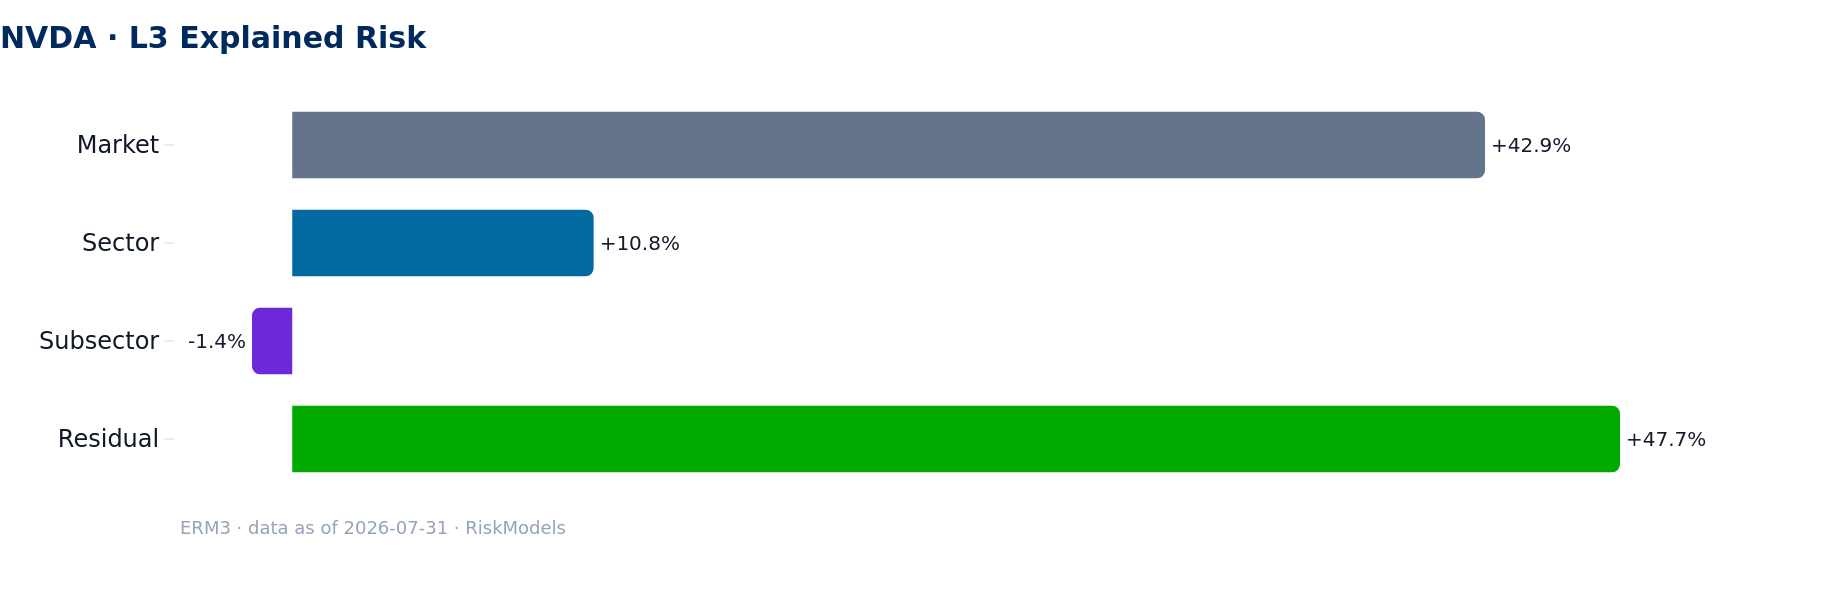

OK  hedge_notionals_hbar  (62,914 bytes)  → NVDA_hedge_notionals_hbar.png


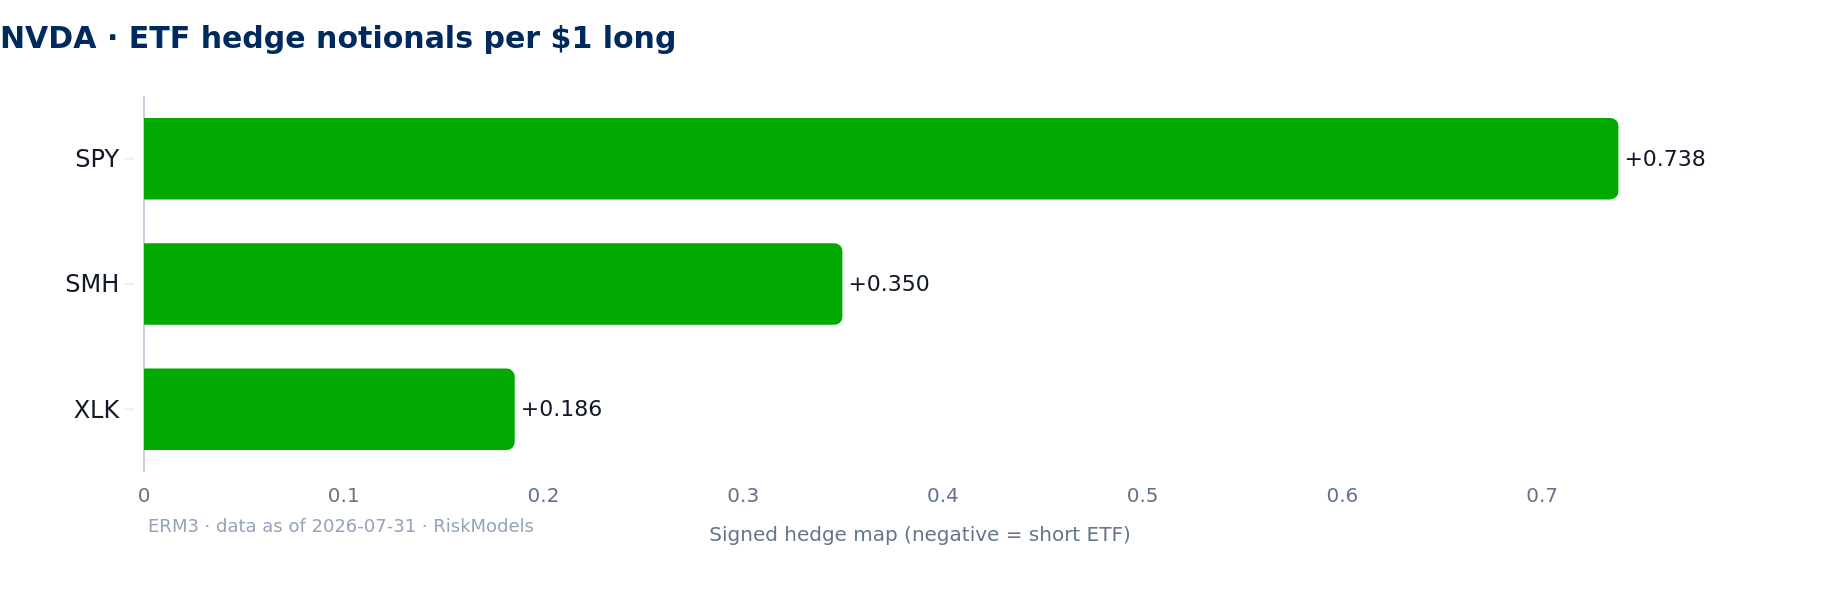

OK  hedge_depth_retained  (74,615 bytes)  → NVDA_hedge_depth_retained.png


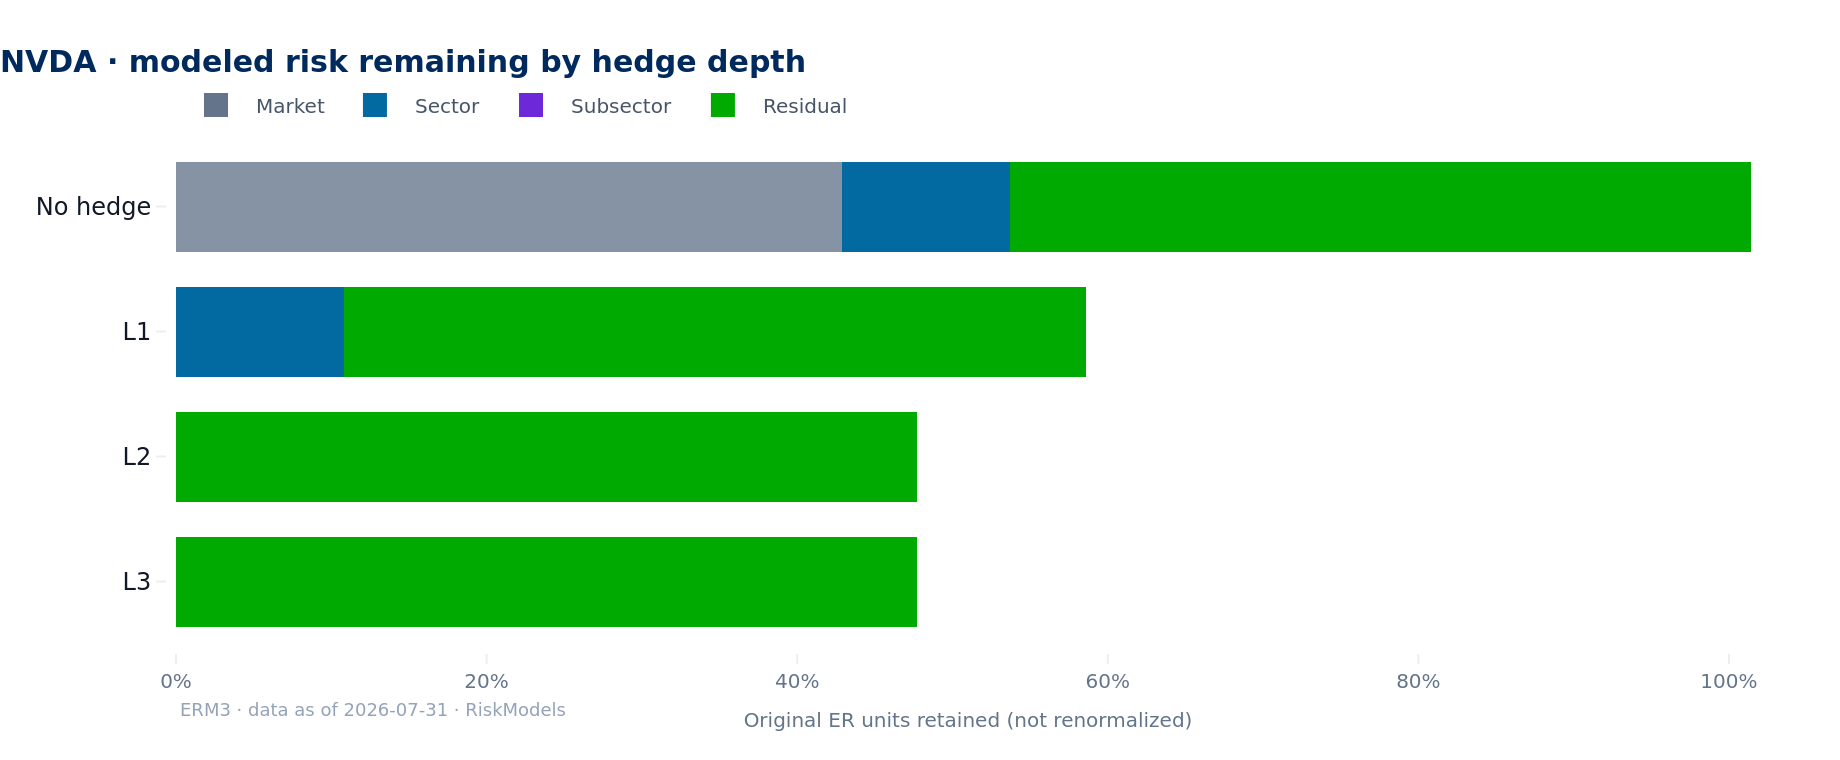

PDF NVDA_metrics_snapshot.pdf (2,952 bytes) — forwardable tearsheet


In [7]:
panel_paths = []
for slug in PANEL_SLUGS:
    try:
        payload, lineage = client.snapshot_panel("stock", STOCK_TICKER, slug, format="png")
        if not isinstance(payload, (bytes, bytearray)):
            print(f"{slug}: unexpected payload type {type(payload)}; skip display")
            continue
        out = OUTPUT_DIR / f"{STOCK_TICKER}_{slug}.png"
        out.write_bytes(payload)
        panel_paths.append(out)
        as_of = getattr(lineage, "data_as_of", None)
        note = f"  as_of={as_of}" if as_of else ""
        print(f"OK  {slug}  ({len(payload):,} bytes){note}  → {out.name}")
        display(Image(data=bytes(payload)))
    except Exception as exc:
        print(f"SKIP {slug}: {exc}")

try:
    pdf_bytes, pdf_lineage = client.get_metrics_snapshot_pdf(STOCK_TICKER)
    pdf_path = OUTPUT_DIR / f"{STOCK_TICKER}_metrics_snapshot.pdf"
    pdf_path.write_bytes(pdf_bytes)
    print(f"PDF {pdf_path.name} ({len(pdf_bytes):,} bytes) — forwardable tearsheet")
except Exception as exc:
    print(f"SKIP metrics snapshot PDF: {exc}")


# Part II · Fund capabilities

## 5 · Resolve a fund

Fund search is free and returns a stable `bw_fund_id` for analytics endpoints.


In [8]:
search_body, search_headers = api_get("/funds/search", q=FUND_QUERY, limit=10)
fund_hits = search_body.get("results") or []
if not fund_hits:
    raise ValueError(f"No fund matched {FUND_QUERY!r}. Try a ticker or part of the fund name.")

hits = pd.DataFrame(fund_hits)
show_cols = [
    c for c in ["ticker", "fund_name", "equity_style_9box", "morningstar_category",
                "net_expense_ratio", "latest_report_date", "bw_fund_id"]
    if c in hits.columns
]
display(hits[show_cols].head(10))

exact = hits[hits.get("ticker", pd.Series(index=hits.index, dtype=str)).astype(str).str.upper() == FUND_QUERY.upper()]
selected = (exact.iloc[0] if not exact.empty else hits.iloc[0]).to_dict()
FUND_ID = selected["bw_fund_id"]
FUND_LABEL = selected.get("ticker") or selected.get("fund_name") or FUND_ID

print("Selected:", FUND_LABEL, "|", selected.get("fund_name"), "|", FUND_ID)
print("Search lineage / cost headers:", {k: v for k, v in search_headers.items() if v})


,ticker,fund_name,equity_style_9box,morningstar_category,net_expense_ratio,latest_report_date,bw_fund_id
0,AGTHX,Growth Fund of America,Large Growth,Large Growth,0.59,2026-05-31,BW-FUND-S000009228


Selected: AGTHX | Growth Fund of America | BW-FUND-S000009228
Search lineage / cost headers: {'cost_usd': '0'}


## 6 · Composed fund snapshot

One call bundles registry metadata, bitemporal dates, holdings-derived returns, diagnostics,
history, peers, and the hedge basket. The fund return identity is the full sequence —
market + sector + subsector + **style (FF2)** + **final residual** (+ a small identity
residual from aggregation). Style is attributed, **not** credited as selection, and carries
no ETF hedge; the fund's tradeable hedge basket (§9) stops at subsector.


,Value
Fund,Growth Fund of America
Ticker,AGTHX
Style cell,Large Growth
Holdings report date,2026-05-31
Filing date,2026-08-14
Model version,funds_dag.v20260720
API cost for this call,0.01


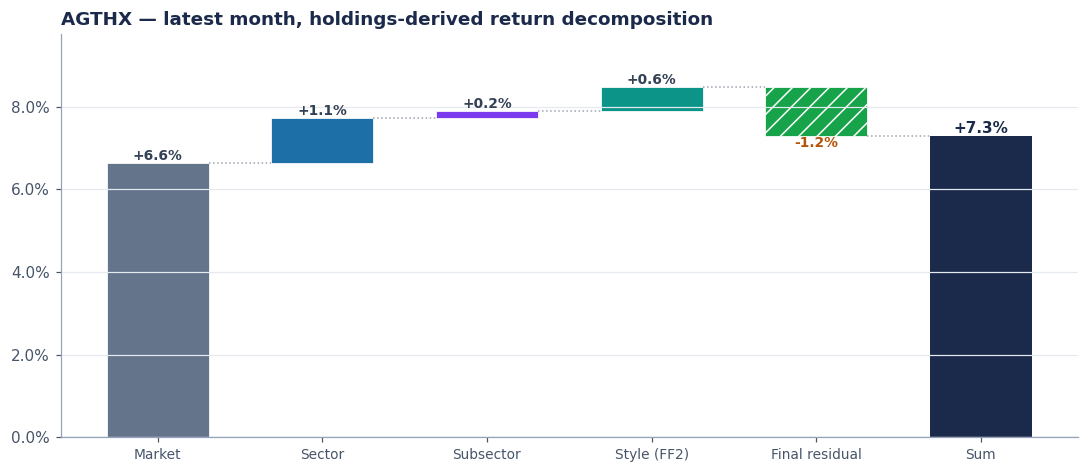

Gross 7.16% | layer sum 7.29% | identity residual -0.130% (holdings-aggregation remainder — reported so the identity is auditable)


In [9]:
fund_snapshot, fund_headers = api_get(f"/funds/snapshot/{FUND_ID}")

fund_metrics = fund_snapshot.get("metrics") or {}
fund_returns = fund_metrics.get("returns") or {}
diagnostics = fund_metrics.get("diagnostics") or {}
metadata = fund_snapshot.get("_metadata") or fund_metrics.get("_metadata") or {}

identity = pd.DataFrame({
    "Value": {
        "Fund": fund_snapshot.get("fund_name") or selected.get("fund_name"),
        "Ticker": fund_snapshot.get("ticker") or selected.get("ticker"),
        "Style cell": fund_snapshot.get("equity_style_9box") or selected.get("equity_style_9box"),
        "Holdings report date": fund_snapshot.get("report_date") or fund_headers.get("data_as_of"),
        "Filing date": fund_snapshot.get("filing_date") or fund_headers.get("filing_date"),
        "Model version": metadata.get("model_version") or fund_headers.get("model_version"),
        "API cost for this call": fund_headers.get("cost_usd"),
    }
})
display(identity)

# The FF2 style layer: prefer the returns block, fall back to the history rows
history_rows = ((fund_snapshot.get("portfolio_history") or {}).get("rows") or [])
style_val = fund_returns.get("style")
if style_val is None and history_rows:
    hist_tmp = pd.DataFrame(history_rows).dropna(subset=["portfolio_gross_return"])
    if not hist_tmp.empty and "portfolio_style_return" in hist_tmp.columns:
        style_val = hist_tmp.iloc[-1]["portfolio_style_return"]

steps = {
    "Market": fund_returns.get("market"),
    "Sector": fund_returns.get("sector"),
    "Subsector": fund_returns.get("subsector"),
    "Style (FF2)": style_val,
    "Final residual": fund_returns.get("idiosyncratic"),
}
steps = {k: v for k, v in steps.items() if v is not None}
gross = fund_returns.get("gross")

fig, ax = plt.subplots(figsize=(10, 4.4))
waterfall(ax, steps, total_label="Sum",
          title=f"{FUND_LABEL} — latest month, holdings-derived return decomposition")
plt.tight_layout()
plt.show()

if gross is not None:
    layer_sum = sum(steps.values())
    print(f"Gross {gross:.2%} | layer sum {layer_sum:.2%} | identity residual {gross - layer_sum:+.3%} "
          "(holdings-aggregation remainder — reported so the identity is auditable)")


## 7 · Is the final residual — the stock-selection sleeve — persistent?

**Final residual** = the holdings-weighted selection sleeve after market / sector /
subsector **and** the FF2 style strip. Style tilt is attributed to its own layer, not
credited as selection — this is the skills-paper skill metric. One month is noise;
persistence is the claim worth testing.


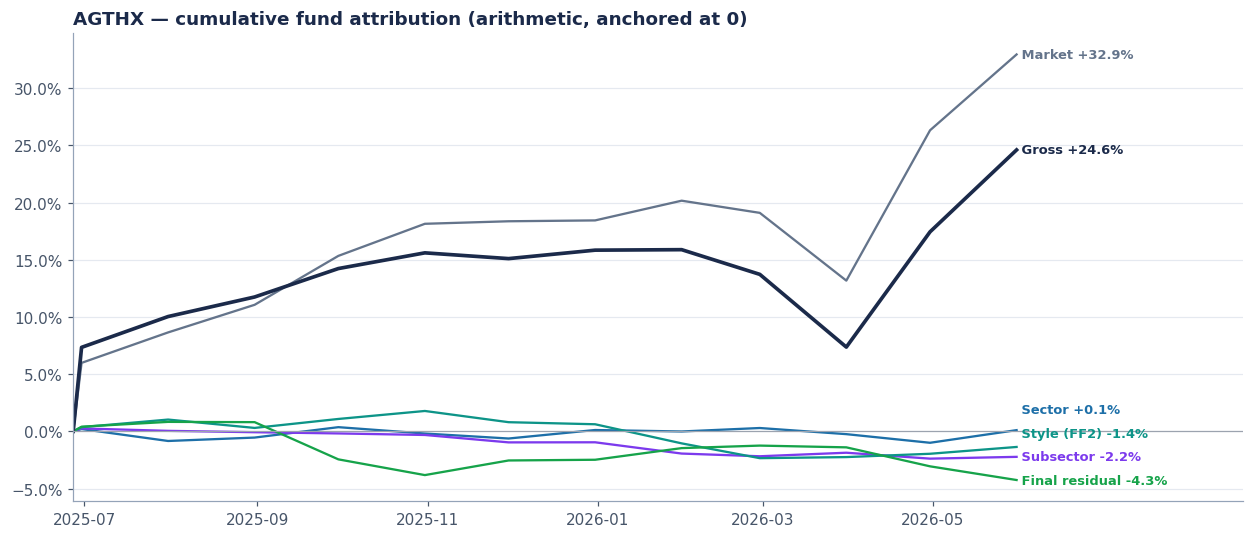

,Value
Observed months,12.00
Positive final-residual months,0.50
Cumulative final residual (selection),-0.04
Cumulative style (FF2) contribution,-0.01


Style vs selection can disagree — that separation is the point of the FF2 layer: without it, style tilt would be booked as stock selection.


In [10]:
fund_history = pd.DataFrame(history_rows)

if fund_history.empty:
    print("No portfolio history in this fund snapshot. Try another fund with a longer holdings panel.")
else:
    fund_history["teo"] = pd.to_datetime(fund_history["teo"])
    fund_history = fund_history.sort_values("teo").reset_index(drop=True)
    fund_history = fund_history.dropna(subset=["portfolio_gross_return"]).reset_index(drop=True)

    rename = {
        "portfolio_market_return": "Market",
        "portfolio_sector_return": "Sector",
        "portfolio_subsector_return": "Subsector",
        "portfolio_style_return": "Style (FF2)",
        "portfolio_idiosyncratic_return": "Final residual",
        "portfolio_gross_return": "Gross",
    }
    available = {k: v for k, v in rename.items() if k in fund_history.columns}
    fund_attr = fund_history[list(available)].rename(columns=available)

    cum_fund = cum_with_t0(fund_attr, fund_history["teo"])
    fig, ax = plt.subplots(figsize=(11.5, 5))
    attribution_lines(ax, cum_fund,
                      title=f"{FUND_LABEL} — cumulative fund attribution (arithmetic, anchored at 0)")
    plt.tight_layout()
    plt.show()

    if "Final residual" in fund_attr:
        resid = fund_attr["Final residual"].dropna()
        persistence = {
            "Observed months": float(len(resid)),
            "Positive final-residual months": (resid > 0).mean() if len(resid) else np.nan,
            "Cumulative final residual (selection)": resid.sum(),
        }
        if "Style (FF2)" in fund_attr:
            persistence["Cumulative style (FF2) contribution"] = fund_attr["Style (FF2)"].sum()
        display(pd.DataFrame({"Value": persistence}))
        if "Style (FF2)" in fund_attr:
            print("Style vs selection can disagree — that separation is the point of the FF2 layer: "
                  "without it, style tilt would be booked as stock selection.")


## 8 · Context: coverage, concentration, holdings, peer rank

Guardrails around any “skill” read.


In [11]:
diagnostic_table = pd.DataFrame({
    "Value": {
        "ERM3 universe coverage": diagnostics.get("weight_sum"),
        "Active holdings": diagnostics.get("n_holdings_active"),
        "Effective N (HHI)": diagnostics.get("effective_n"),
        "Top-10 weight": diagnostics.get("top10_weight_sum"),
    }
})
display(diagnostic_table)

holdings_block = fund_snapshot.get("holdings") or {}
top_holdings = pd.DataFrame(holdings_block.get("top") or [])
if not top_holdings.empty:
    holding_cols = [c for c in ["bw_sym_id", "weight", "adj_mv"] if c in top_holdings.columns]
    holdings_display = top_holdings[holding_cols].head(10).copy()
    if "weight" in holdings_display:
        holdings_display["weight"] = holdings_display["weight"].map(
            lambda x: f"{x:.2%}" if pd.notna(x) else "—"
        )
    if "adj_mv" in holdings_display:
        holdings_display["adj_mv"] = holdings_display["adj_mv"].map(
            lambda x: f"${x:,.0f}" if pd.notna(x) else "—"
        )
    display(holdings_display)
else:
    print("No holdings block in this snapshot.")

ranks = pd.DataFrame(((fund_snapshot.get("cohort_context") or {}).get("ranks") or []))
if not ranks.empty:
    if {"rank", "cohort_size"}.issubset(ranks.columns):
        ranks["percentile"] = np.where(
            ranks["cohort_size"].fillna(0) > 1,
            100 * (1 - (ranks["rank"] - 1) / ranks["cohort_size"]),
            np.nan,
        )
    rank_cols = [c for c in ["metric", "period_window", "rank", "cohort_size", "percentile", "value"] if c in ranks.columns]
    display(ranks[rank_cols].sort_values([c for c in ["metric", "period_window"] if c in rank_cols]))
else:
    print("No peer ranks are available for this fund/style-date combination.")


,Value
ERM3 universe coverage,1.00
Active holdings,192.00
Effective N (HHI),33.40
Top-10 weight,0.47


,bw_sym_id,weight,adj_mv
0,BW-BBG000BBJQV0,8.95%,"$19,892,735,203"
1,BW-BBG000MM2P62,6.27%,"$13,941,763,253"
2,BW-BBG000BPH459,5.95%,"$13,231,720,079"
3,BW-BBG000BNBDC2,4.91%,"$10,909,869,537"
4,BW-BBG009S3NB30,4.31%,"$9,585,889,209"
5,BW-BBG000BVPV84,4.22%,"$9,374,217,930"
6,BW-BBG000N9MNX3,3.82%,"$8,493,404,164"
7,BW-BBG000C1S2X2,3.08%,"$6,839,883,452"
8,BW-BBG000B9XRY4,2.70%,"$5,997,378,167"
9,BW-BBG000C5Z1S3,2.61%,"$5,811,386,080"


,metric,period_window,rank,cohort_size,percentile,value
0,effective_n,1m,8,421,98.34,None
1,n_holdings_active,1m,21,421,95.25,None
2,total_adj_mv,1m,2,421,99.76,None
3,weight_sum,1m,3,421,99.52,None


## 9 · Fund hedge basket (+ dollar ticket)

Same HR convention as stocks: ETF notional per $1 of fund exposure, scaled by
`NOTIONAL_USD`. The basket stops at subsector — the tradeable depth of the cascade;
style and final residual have no hedge legs by construction.


,Level,ETF,HR ($ ETF / $1 fund),Notional hedge ($)
0,L1,SPY,-1.1934,"$-11,934,366"
1,L2,SPY,-0.2880,"$-2,879,965"
2,L2,XLB,-0.0141,"$-140,721"
3,L2,XLC,-0.1100,"$-1,100,264"
4,L2,XLE,-0.0145,"$-144,854"
...,...,...,...,...
57,L3,XLY,-0.1072,"$-1,071,706"
58,L3,XME,-0.0011,"$-10,667"
59,L3,XOP,-0.0040,"$-39,975"
60,L3,XPH,-0.0044,"$-43,558"


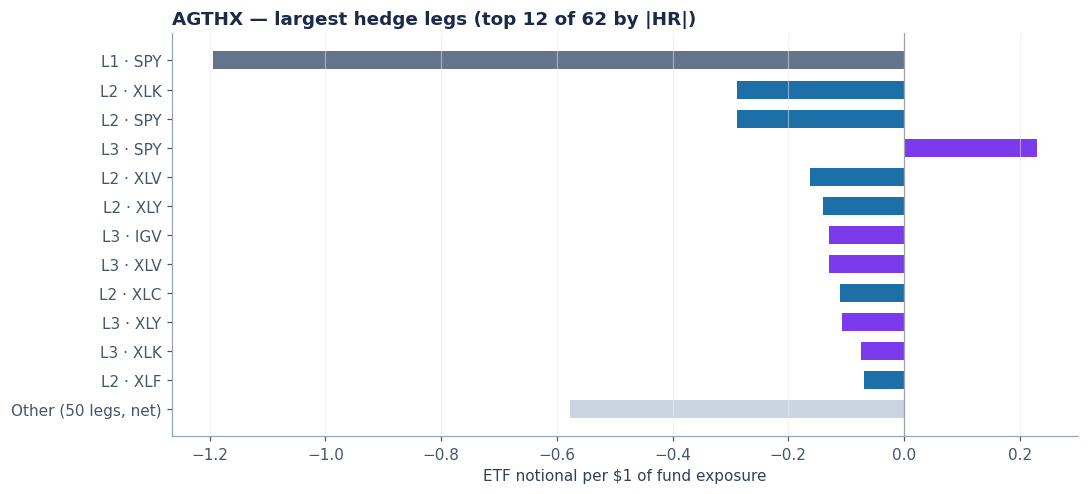

In [12]:
hedge_block = fund_snapshot.get("hedge") or {}
hedge_rows = []
for level in ["L1", "L2", "L3"]:
    for leg in hedge_block.get(level) or []:
        hedge_rows.append({"Level": level, "ETF": leg.get("etf"), "HR ($ ETF / $1 fund)": leg.get("hr")})

fund_hedge = pd.DataFrame(hedge_rows)
if fund_hedge.empty:
    print("No fund hedge basket is available for this snapshot.")
else:
    fund_hedge["Notional hedge ($)"] = fund_hedge["HR ($ ETF / $1 fund)"] * NOTIONAL_USD
    fund_hedge_display = fund_hedge.copy()
    fund_hedge_display["HR ($ ETF / $1 fund)"] = fund_hedge_display["HR ($ ETF / $1 fund)"].map(
        lambda x: f"{x:.4f}" if pd.notna(x) else "—"
    )
    fund_hedge_display["Notional hedge ($)"] = fund_hedge_display["Notional hedge ($)"].map(
        lambda x: f"${x:,.0f}" if pd.notna(x) else "—"
    )
    display(fund_hedge_display)

    plotted = fund_hedge.dropna(subset=["HR ($ ETF / $1 fund)"]).copy()
    top = plotted.reindex(plotted["HR ($ ETF / $1 fund)"].abs().sort_values(ascending=False).index).head(12)
    rest = plotted.drop(top.index)
    top = top.iloc[::-1]

    level_color = {"L1": LAYER_COLORS["Market"], "L2": LAYER_COLORS["Sector"], "L3": LAYER_COLORS["Subsector"]}
    fig, ax = plt.subplots(figsize=(10, 4.6))
    labels = (top["Level"] + " · " + top["ETF"].astype(str)).tolist()
    values = top["HR ($ ETF / $1 fund)"].tolist()
    colors = top["Level"].map(level_color).tolist()
    if not rest.empty:
        labels = [f"Other ({len(rest)} legs, net)"] + labels
        values = [rest["HR ($ ETF / $1 fund)"].sum()] + values
        colors = ["#CBD5E1"] + colors
    ax.barh(labels, values, color=colors, height=0.62)
    ax.axvline(0, color="#9CA3AF", lw=0.8)
    ax.grid(axis="x", alpha=0.5)
    ax.grid(axis="y", visible=False)
    ax.set_xlabel("ETF notional per $1 of fund exposure")
    ax.set_title(f"{FUND_LABEL} — largest hedge legs (top 12 of {len(plotted)} by |HR|)", loc="left")
    plt.tight_layout()
    plt.show()


# Part III · Bring your book

Omega Point already pipes client portfolios through hosted models. This cell POSTs a tiny weight vector to RiskModels — the same pattern you would use to host Orth Risk next to Barra.


Book: {'NVDA': 0.25, 'AAPL': 0.25, 'MSFT': 0.25, 'JPM': 0.25}


,l3_market_er,l3_sector_er,l3_subsector_er,l3_residual_er
L3 ER (weight-mean),0.24,0.13,0.08,0.55


,portfolio_hedge_ratios
l1_market_hr,-1.03
l2_market_hr,-0.67
l2_sector_hr,-0.39
l3_market_hr,-0.74
l3_sector_hr,-0.15
l3_subsector_hr,-0.21


,ticker,l1_market_hr,l1_market_er,l1_residual_er,l2_market_hr,l2_sector_hr,l2_market_er,l2_sector_er,l2_residual_er,l3_market_hr,l3_sector_hr,l3_subsector_hr,l3_market_er,l3_sector_er,l3_subsector_er,l3_residual_er,lstar_residual_return
ticker,,,,,,,,,,,,,,,,,
NVDA,NVDA,-1.87,0.43,0.57,-0.37,-0.88,0.43,0.11,0.46,-0.74,-0.19,-0.35,0.43,0.11,-0.01,0.48,0.02
AAPL,AAPL,-0.74,0.19,0.81,-1.10,0.21,0.19,0.02,0.79,-1.03,-0.01,0.18,0.19,0.02,0.00,0.79,-0.08
MSFT,MSFT,-0.79,0.12,0.88,-1.24,0.26,0.12,0.01,0.87,-1.24,0.67,-0.61,0.12,0.01,0.34,0.53,0.02
JPM,JPM,-0.72,0.20,0.80,0.02,-1.16,0.20,0.39,0.41,0.04,-1.09,-0.07,0.20,0.39,-0.01,0.42,0.00


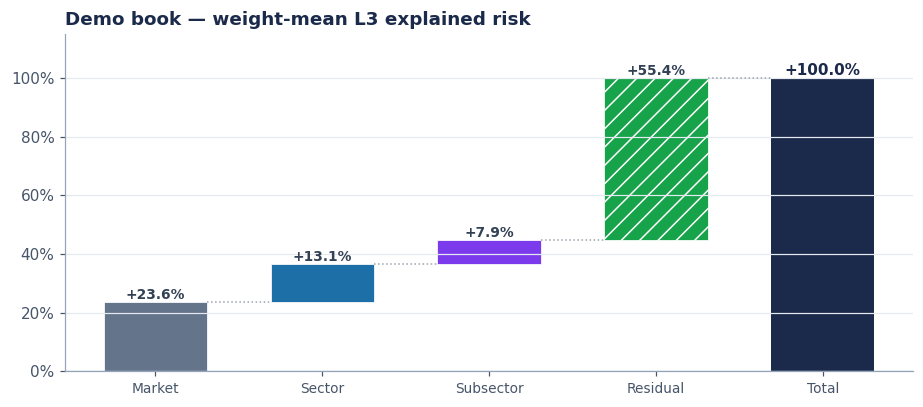

Book PDF → output/demo_book_risk_snapshot.pdf (3,200 bytes)


In [13]:
pa = client.analyze_portfolio(BOOK, metrics=["full_metrics", "hedge_ratios"], years=1)
print("Book:", BOOK)

# Portfolio-level ER / HR aggregates when present
er_port = getattr(pa, "portfolio_l3_er_weighted_mean", None)
hr_port = getattr(pa, "portfolio_hedge_ratios", None)
if er_port is not None:
    display(pd.DataFrame({"L3 ER (weight-mean)": er_port}).T if not isinstance(er_port, pd.DataFrame) else er_port)
if hr_port is not None:
    display(hr_port if isinstance(hr_port, pd.DataFrame) else pd.DataFrame({"portfolio_hedge_ratios": hr_port}))

per = getattr(pa, "per_ticker", None)
if per is not None:
    if isinstance(per, pd.DataFrame):
        cols = [c for c in per.columns if any(k in c for k in ("er", "hr", "ticker", "residual"))]
        display(per[cols].head(20) if cols else per.head(20))
    else:
        print(per)

if er_port is not None:
    if isinstance(er_port, pd.DataFrame):
        er_map = er_port.iloc[0].to_dict()
    elif isinstance(er_port, pd.Series):
        er_map = er_port.to_dict()
    else:
        er_map = dict(er_port)
    er_steps = {
        "Market": er_map.get("l3_market_er"),
        "Sector": er_map.get("l3_sector_er"),
        "Subsector": er_map.get("l3_subsector_er"),
        "Residual": er_map.get("l3_residual_er"),
    }
    er_steps = {k: float(v) for k, v in er_steps.items() if v is not None and pd.notna(v)}
    if er_steps:
        fig, ax = plt.subplots(figsize=(8.5, 3.8))
        waterfall(ax, er_steps, total_label="Total",
                  title="Demo book — weight-mean L3 explained risk")
        plt.tight_layout()
        plt.show()

try:
    book_pdf, book_lineage = client.post_portfolio_risk_snapshot_pdf(BOOK, title="Omega demo book")
    book_pdf_path = OUTPUT_DIR / "demo_book_risk_snapshot.pdf"
    book_pdf_path.write_bytes(book_pdf)
    print(f"Book PDF → {book_pdf_path} ({len(book_pdf):,} bytes)")
except TypeError:
    # Older SDK may not accept title=
    try:
        book_pdf, book_lineage = client.post_portfolio_risk_snapshot_pdf(BOOK)
        book_pdf_path = OUTPUT_DIR / "demo_book_risk_snapshot.pdf"
        book_pdf_path.write_bytes(book_pdf)
        print(f"Book PDF → {book_pdf_path} ({len(book_pdf):,} bytes)")
    except Exception as exc:
        print(f"SKIP book PDF: {exc}")
except Exception as exc:
    print(f"SKIP book PDF: {exc}")


# Takeaways for a model host

1. **Orth Risk is a model to host**, not a replacement for Omega Point's platform or for
   Barra — the same multi-model shelf pattern you already run.
2. **The full sequence is served over one API**: market → sector → subsector → FF2 style →
   final residual. Hedge legs stop at subsector — one liquid ETF each, signed dollar
   tickets. FF2 carries no ETF hedge; it is the layer that keeps style tilt out of the
   selection read.
3. **L\*** turns the negative-ER subtlety into product: the API dispatches the hedge depth
   per name per day (NVDA today: L2 — skip the SMH leg), and the L\* residual is the
   skills-paper ranking feature.
4. **Interpretation discipline:** the final residual is selection *after* the full
   sequence. AGTHX's trailing year shows why the layers must be separated — style and
   selection moved in opposite directions. Persistence, not one month, is the skill claim.

**Question for the room:** would you host Orth Risk — signed hierarchical ER, ETF hedge
tickets, L\* dispatch, and the final-residual fund view — alongside Barra?
